# ZAJECIA 3 - DANE Z INTERNETU, ANALIZA I WIZUALIZACJA
**Wydzial Zarzadzania UW**

Na tych zajeciach nauczymy sie:
- pobierac dane z internetu (`requests`)
- obslugiwac bledy (`try / except`)
- analizowac dane dla wielu spolek jednoczesnie
- wizualizowac wyniki (`matplotlib`)

---
## 7. POBIERANIE DANYCH Z INTERNETU - BIBLIOTEKA requests

W prawdziwej analizie danych rzadko tworzymy dane recznie - czesciej pobieramy je z zewnetrznych zrodel.
Biblioteka `requests` pozwala wykonywac zapytania HTTP, czyli komunikowac sie z serwisami webowymi i API.

Skorzystamy z serwisu **stooq.pl**, ktory udostepnia historyczne dane kursow akcji w formacie CSV.

Kolumny zwracane przez stooq.pl: `Data`, `Otwarcie`, `Najwyzszy`, `Najnizszy`, `Zamkniecie`, `Wolumen`

### 7.1 Jak dziala requests - podstawy

In [59]:
import requests
import pandas as pd
import numpy as np
import io

# Wysylamy zapytanie GET - jak wpisanie adresu w przegladarce
url = 'https://stooq.pl/q/d/l/?s=pko&i=d'
response = requests.get(url)

print("Kod statusu:", response.status_code)   # 200 = sukces
print("Typ tresci:", response.headers['Content-Type'])
print()
print(response.text[:300])

Kod statusu: 200
Typ tresci: text/plain

Data,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie,Wolumen
2004-11-10,11.7996,12.5114,11.7996,12.4614,114992709.35277
2004-11-12,12.4614,13.1226,12.4614,12.5627,41084394.793899
2004-11-15,12.4614,12.5627,12.2603,12.5114,17090452.259078
2004-11-16,12.4614,12.5114,12.4107,12.4614,7756547.4683053
2004-1


> **Kod statusu HTTP:**
> - `200` - OK, zapytanie sie powiodlo
> - `404` - nie znaleziono zasobu
> - `403` - brak dostepu
> - `500` - blad serwera

Adres URL na stooq.pl ma nastepujaca strukture:
```
https://stooq.pl/q/d/l/?s=TICKER&i=d
```
gdzie `s=` to ticker spolki (np. `pko`, `cdr`, `kgh`), a `i=d` oznacza dane dzienne.

### 7.2 Wczytanie danych jednej spolki do DataFrame

In [ ]:
def pobierz_dane_spolki(ticker, nazwa=None):
    """
    Pobiera historyczne dane kursow akcji ze stooq.pl.
    ticker: symbol spolki (np. 'pko', 'cdr', 'kgh')
    nazwa:  opcjonalna czytelna nazwa spolki
    Zwraca DataFrame z kolumnami: Data, Otwarcie, Najwyzszy, Najnizszy, Zamkniecie, Wolumen
    """
    url = f'https://stooq.pl/q/d/l/?s={ticker}&i=d'
    response = requests.get(url)
    if response.status_code != 200:
        print(f"Blad pobierania danych dla {ticker}: status {response.status_code}")
        return None
    df = pd.read_csv(io.StringIO(response.text))
    df['Data'] = pd.to_datetime(df['Data'])
    df = df.sort_values('Data').reset_index(drop=True)
    df['ticker'] = ticker.upper()
    if nazwa:
        df['spolka'] = nazwa
    return df

df_pko = pobierz_dane_spolki('pko', 'PKO BP')
print(df_pko.shape)
df_pko.head()

(5339, 8)


,Data,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie,Wolumen,ticker,spolka
0,2004-11-10,11.7996,12.5114,11.7996,12.4614,1.149927e+08,PKO,PKO BP
1,2004-11-12,12.4614,13.1226,12.4614,12.5627,4.108439e+07,PKO,PKO BP
2,2004-11-15,12.4614,12.5627,12.2603,12.5114,1.709045e+07,PKO,PKO BP
3,2004-11-16,12.4614,12.5114,12.4107,12.4614,7.756547e+06,PKO,PKO BP
4,2004-11-17,12.4614,12.5114,12.3600,12.4614,6.402894e+06,PKO,PKO BP


In [60]:
df_pko.tail(5)

,Data,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie,Wolumen,ticker,spolka
5334,2026-03-09,83.00,85.08,80.80,85.08,3438778.0,PKO,PKO BP
5335,2026-03-10,87.50,89.10,87.40,87.80,3223132.0,PKO,PKO BP
5336,2026-03-11,88.00,88.34,86.68,87.60,2853922.0,PKO,PKO BP
5337,2026-03-12,88.02,88.30,84.54,86.02,2338430.0,PKO,PKO BP
5338,2026-03-13,86.06,87.68,85.02,86.52,2702057.0,PKO,PKO BP


In [61]:
df_pko.dtypes

Data          datetime64[us]
Otwarcie             float64
Najwyzszy            float64
Najnizszy            float64
Zamkniecie           float64
Wolumen              float64
ticker                   str
spolka                   str
dtype: object

### 7.3 Podstawowe operacje na danych kursowych

In [62]:
# Filtrowanie po roku – .dt pozwala wyciagnac czesci daty
df_pko_2024 = df_pko[df_pko['Data'].dt.year == 2024].copy()
print(f"Liczba sesji w 2024 roku: {len(df_pko_2024)}")
df_pko_2024.head()

Liczba sesji w 2024 roku: 249


,Data,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie,Wolumen,ticker,spolka
4791,2024-01-02,43.3695,43.6114,42.2378,42.8771,1.812549e+06,PKO,PKO BP
4792,2024-01-03,42.7820,43.2313,42.3674,43.2313,3.376238e+06,PKO,PKO BP
4793,2024-01-04,43.1104,43.1881,42.2118,42.9721,3.134298e+06,PKO,PKO BP
4794,2024-01-05,42.5142,43.1017,41.4862,42.9721,4.056338e+06,PKO,PKO BP
4795,2024-01-08,42.7734,43.5077,42.3328,43.3868,3.079264e+06,PKO,PKO BP


In [63]:
print("Statystyki kursu PKO BP w 2024:")
print(f"  Minimum:  {df_pko_2024['Zamkniecie'].min():.2f} PLN")
print(f"  Maksimum: {df_pko_2024['Zamkniecie'].max():.2f} PLN")
print(f"  Srednia:  {df_pko_2024['Zamkniecie'].mean():.2f} PLN")
print(f"  Mediana:  {df_pko_2024['Zamkniecie'].median():.2f} PLN")

Statystyki kursu PKO BP w 2024:
  Minimum:  41.86 PLN
  Maksimum: 57.20 PLN
  Srednia:  51.34 PLN
  Mediana:  52.13 PLN


In [65]:
type(df_pko_2024['Zamkniecie'])

pandas.Series

In [71]:
df_pko_2024.head()

,Data,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie,Wolumen,ticker,spolka
4791,2024-01-02,43.3695,43.6114,42.2378,42.8771,1.812549e+06,PKO,PKO BP
4792,2024-01-03,42.7820,43.2313,42.3674,43.2313,3.376238e+06,PKO,PKO BP
4793,2024-01-04,43.1104,43.1881,42.2118,42.9721,3.134298e+06,PKO,PKO BP
4794,2024-01-05,42.5142,43.1017,41.4862,42.9721,4.056338e+06,PKO,PKO BP
4795,2024-01-08,42.7734,43.5077,42.3328,43.3868,3.079264e+06,PKO,PKO BP


In [68]:
idx_max

5028

In [ ]:
idx_max = df_pko_2024['Zamkniecie'].idxmax()
print("Najwyzszy kurs zamkniecia:")
print(df_pko_2024.loc[idx_max, ['Data', 'Zamkniecie', 'Wolumen']])

Najwyzszy kurs zamkniecia:


Data          2024-12-10 00:00:00
Zamkniecie                57.1983
Wolumen              3162595.4366
Name: 5028, dtype: object

In [83]:
df_pko_2024.nlargest(5, 'zmiana_pct')[['Data', 'Zamkniecie', 'zmiana_pct']]

,Data,Zamkniecie,zmiana_pct
4814,2024-02-02,47.4799,4.570452
4869,2024-04-23,55.4966,4.091907
4945,2024-08-12,50.3912,4.083298
5003,2024-11-04,54.0465,3.871057
4865,2024-04-17,51.3818,3.723457


In [ ]:
# Dzienna zmiana procentowa kursu – .pct_change()
df_pko_2024['zmiana_pct'] = df_pko_2024['Zamkniecie'].pct_change() * 100

print("Top 5 wzrostow:")
print(df_pko_2024.nlargest(5, 'zmiana_pct')[['Data', 'Zamkniecie', 'zmiana_pct']])
print()
print("Top 5 spadkow:")
print(df_pko_2024.nsmallest(5, 'zmiana_pct')[['Data', 'Zamkniecie', 'zmiana_pct']])

Top 5 wzrostow:
           Data  Zamkniecie  zmiana_pct
4814 2024-02-02     47.4799    4.570452
4869 2024-04-23     55.4966    4.091907
4945 2024-08-12     50.3912    4.083298
5003 2024-11-04     54.0465    3.871057
4865 2024-04-17     51.3818    3.723457

Top 5 spadkow:
           Data  Zamkniecie  zmiana_pct
4880 2024-05-10     51.0448   -5.047769
4896 2024-06-04     49.8211   -4.779643
5011 2024-11-15     52.5732   -4.634652
4966 2024-09-11     50.3725   -4.524666
4864 2024-04-16     49.5373   -3.987433


In [89]:
df_pko_2024.groupby('miesiac')['Zamkniecie'].mean().round(2)

miesiac
1     43.06
2     47.78
3     49.91
4     53.03
5     51.86
6     52.45
7     53.66
8     51.07
9     52.99
10    52.45
11    52.65
12    56.05
Name: Zamkniecie, dtype: float64

In [ ]:
# Sredni kurs zamkniecia wg miesiaca
df_pko_2024['miesiac'] = df_pko_2024['Data'].dt.month
print(df_pko_2024.groupby('miesiac')['Zamkniecie'].mean().round(2))

miesiac
1     43.06
2     47.78
3     49.91
4     53.03
5     51.86
6     52.45
7     53.66
8     51.07
9     52.99
10    52.45
11    52.65
12    56.05
Name: Zamkniecie, dtype: float64


### 7.4 Porownanie kilku spolek

In [32]:
spolki = {
    'pko':  'PKO BP',
    'cdr':  'CD Projekt',
    'kgh':  'KGHM',
    'pge':  'PGE',
    'lpp':  'LPP'
}

lista_df = []
for ticker, nazwa in spolki.items():
    df_tmp = pobierz_dane_spolki(ticker, nazwa)
    if df_tmp is not None:
        lista_df.append(df_tmp)
        print(f"Pobrano: {nazwa} ({ticker.upper()}) - {len(df_tmp)} sesji")

df_wszystkie = pd.concat(lista_df, ignore_index=True)
print(f"\nLacznie wierszy: {len(df_wszystkie)}")

Pobrano: PKO BP (PKO) - 5339 sesji
Pobrano: CD Projekt (CDR) - 7856 sesji
Pobrano: KGHM (KGH) - 7175 sesji
Pobrano: PGE (PGE) - 4085 sesji
Pobrano: LPP (LPP) - 6146 sesji

Lacznie wierszy: 30601


In [33]:
df_wszystkie

,Data,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie,Wolumen,ticker,spolka
0,2004-11-10,11.7996,12.5114,11.7996,12.4614,1.149927e+08,PKO,PKO BP
1,2004-11-12,12.4614,13.1226,12.4614,12.5627,4.108439e+07,PKO,PKO BP
2,2004-11-15,12.4614,12.5627,12.2603,12.5114,1.709045e+07,PKO,PKO BP
3,2004-11-16,12.4614,12.5114,12.4107,12.4614,7.756547e+06,PKO,PKO BP
4,2004-11-17,12.4614,12.5114,12.3600,12.4614,6.402894e+06,PKO,PKO BP
...,...,...,...,...,...,...,...,...
30596,2026-03-09,19350.0000,19450.0000,18940.0000,19390.0000,2.812000e+03,LPP,LPP
30597,2026-03-10,19745.0000,19930.0000,19650.0000,19920.0000,2.556000e+03,LPP,LPP
30598,2026-03-11,19930.0000,20000.0000,19310.0000,19445.0000,3.361000e+03,LPP,LPP
30599,2026-03-12,19360.0000,19575.0000,19155.0000,19360.0000,3.881000e+03,LPP,LPP


In [34]:
def stopa_zwrotu(df_spolka):
    df_s        = df_spolka.sort_values('Data')
    kurs_start  = df_s.iloc[0]['Zamkniecie']
    kurs_koniec = df_s.iloc[-1]['Zamkniecie']
    return round((kurs_koniec / kurs_start - 1) * 100, 2)

df_2024 = df_wszystkie[df_wszystkie['Data'].dt.year == 2024].copy()

wyniki = []
for spolka, df_s in df_2024.groupby('spolka'):
    wyniki.append({'spolka': spolka, 'stopa_zwrotu_pct': stopa_zwrotu(df_s)})

df_wyniki = pd.DataFrame(wyniki).sort_values('stopa_zwrotu_pct', ascending=False)
df_wyniki

,spolka,stopa_zwrotu_pct
0,CD Projekt,72.34
4,PKO BP,29.96
2,LPP,2.91
1,KGHM,-3.32
3,PGE,-29.19


In [12]:
# Pivot table – wiersze = daty, kolumny = spolki, wartosci = kurs zamkniecia
df_pivot = df_2024.pivot_table(index='Data', columns='spolka', values='Zamkniecie')
df_pivot.corr().round(2)

spolka,CD Projekt,KGHM,LPP,PGE,PKO BP
spolka,,,,,
CD Projekt,1.00,0.49,-0.06,-0.55,0.65
KGHM,0.49,1.00,0.22,-0.42,0.57
LPP,-0.06,0.22,1.00,-0.00,0.19
PGE,-0.55,-0.42,-0.00,1.00,-0.75
PKO BP,0.65,0.57,0.19,-0.75,1.00


---
## 8. OBSLUGA BLEDOW - try / except

Gdy pobieramy dane z internetu dla wielu spolek, zawsze cos moze pojsc nie tak:
- brak danych za dany okres
- spolka zawieszona lub wycofana z gieldy
- chwilowy blad serwera
- odpowiedz w nieoczekiwanym formacie

Mechanizm `try / except` pozwala wylapac blad i kontynuowac dzialanie zamiast zatrzymywac caly program.

### 8.1 Podstawowa skladnia try / except

In [36]:
# BEZ obslugi bledow – program sie wysypie przy n == 0
liczby = [10, 0, 5]
for n in liczby:
    wynik = 100 / n
    print(wynik)

10.0


ZeroDivisionError: division by zero

In [38]:
# Z obsluga bledow – program dziala dalej
liczby = [10, 0, 5]
for n in liczby:
    try:
        wynik = 100 / n
        print(f"100 / {n} = {wynik}")
    except ZeroDivisionError:
        print(f"Blad: nie mozna dzielic przez {n}, pomijam")

100 / 10 = 10.0
Blad: nie mozna dzielic przez 0, pomijam
100 / 5 = 20.0


In [39]:
# Kilka typow bledow jednoczesnie + blok finally
dane = ["42", "abc", None, "7"]

for d in dane:
    try:
        wynik = int(d) * 2
        print(f"Wynik: {wynik}")
    except TypeError:
        print(f"Blad typu: {d!r} to None, nie mozna konwertowac")
    except ValueError:
        print(f"Blad wartosci: {d!r} nie jest liczba")
    finally:
        pass   # finally wykonuje sie ZAWSZE

Wynik: 84
Blad wartosci: 'abc' nie jest liczba
Blad typu: None to None, nie mozna konwertowac
Wynik: 14


In [40]:
# Przechwycenie kazdego bledu (Exception) – uzywaj ostrozenie
try:
    wynik = 1 / 0
except Exception as e:
    print(f"Wystapil blad: {type(e).__name__}: {e}")

Wystapil blad: ZeroDivisionError: division by zero


> **Kiedy uzywac try/except?**
> - Przy operacjach sieciowych (pobieranie danych, API)
> - Przy czytaniu plikow (plik moze nie istniec)
> - Przy konwersjach typow (dane moga byc niekompletne)
> - W petlach przetwarzajacych wiele elementow – zeby jeden blad nie zatrzymal calosci

### 8.2 Odporna funkcja pobierania danych

In [17]:
import time

HEADERS = {
    'User-Agent': (
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/124.0.0.0 Safari/537.36'
    )
}

def pobierz_dane_odporna(ticker, data_od='2020-01-01', data_do='2025-12-31', nazwa=None):
    """
    Pobiera dane historyczne ze stooq.pl z pelna obsluga bledow.
    Nowe elementy vs poprzednia wersja:
      - filtrowanie zakresu dat juz w URL (parametry d1, d2)
      - naglowek User-Agent
      - try/except na kazdym etapie
      - sprawdzenie czy odpowiedz zawiera sensowne dane
    """
    d1  = data_od.replace('-', '')
    d2  = data_do.replace('-', '')
    url = f'https://stooq.pl/q/d/l/?s={ticker}&d1={d1}&d2={d2}&i=d'

    try:
        response = requests.get(url, headers=HEADERS, timeout=10)
        response.raise_for_status()
    except requests.exceptions.Timeout:
        print(f"  [{ticker}] Timeout – serwer nie odpowiedzial")
        return None
    except requests.exceptions.HTTPError as e:
        print(f"  [{ticker}] Blad HTTP: {e}")
        return None
    except requests.exceptions.RequestException as e:
        print(f"  [{ticker}] Blad polaczenia: {e}")
        return None

    try:
        df = pd.read_csv(io.StringIO(response.text))
        if 'Data' not in df.columns:
            print(f"  [{ticker}] Brak kolumny Data – nieprawidlowy ticker lub brak danych")
            return None
        if len(df) == 0:
            print(f"  [{ticker}] Brak danych za podany okres")
            return None
        df['Data']   = pd.to_datetime(df['Data'])
        df['ticker'] = ticker.upper()
        df['spolka'] = nazwa or ticker.upper()
        return df.sort_values('Data').reset_index(drop=True)
    except Exception as e:
        print(f"  [{ticker}] Blad parsowania: {type(e).__name__}: {e}")
        return None

# Test
print("=== Poprawny ticker ===")
df_test = pobierz_dane_odporna('pko', nazwa='PKO BP')
print(f"Pobrano {len(df_test)} wierszy\n")

print("=== Nieistniejacy ticker ===")
df_bad = pobierz_dane_odporna('xyz_nieistniejacy')
print(f"Wynik: {df_bad}")

=== Poprawny ticker ===
Pobrano 1502 wierszy

=== Nieistniejacy ticker ===
  [xyz_nieistniejacy] Brak kolumny Data – nieprawidlowy ticker lub brak danych
Wynik: None


---
## 9. ANALIZA STOP ZWROTU – SPOLKI WIG20

### 9.1 Lista spolek WIG20 i pobieranie danych

In [41]:
# Sklad indeksu WIG20 (stan na 13-03-2026)
# Tickery sa pisane malymi literami – tak jak przyjmuje stooq.pl
wig20 = [
    {'nazwa': 'Allegro',      'ticker': 'ale'},
    {'nazwa': 'Alior Bank',   'ticker': 'alr'},
    {'nazwa': 'Budimex',      'ticker': 'bdx'},
    {'nazwa': 'CD Projekt',   'ticker': 'cdr'},
    {'nazwa': 'Dino Polska',  'ticker': 'dnp'},
    {'nazwa': 'KGHM',         'ticker': 'kgh'},
    {'nazwa': 'Kruk',         'ticker': 'kru'},
    {'nazwa': 'Kety',         'ticker': 'kty'},
    {'nazwa': 'LPP',          'ticker': 'lpp'},
    {'nazwa': 'mBank',        'ticker': 'mbk'},
    {'nazwa': 'Modivo',       'ticker': 'mdv'},
    {'nazwa': 'Orange PL',    'ticker': 'opl'},
    {'nazwa': 'Pepco',        'ticker': 'pco'},
    {'nazwa': 'Pekao',        'ticker': 'peo'},
    {'nazwa': 'PGE',          'ticker': 'pge'},
    {'nazwa': 'PKN Orlen',    'ticker': 'pkn'},
    {'nazwa': 'PKO BP',       'ticker': 'pko'},
    {'nazwa': 'PZU',          'ticker': 'pzu'},
    {'nazwa': 'Santander PL', 'ticker': 'spl'},
    {'nazwa': 'Zabka',        'ticker': 'zab'},
]

df_spolki = pd.DataFrame(wig20)
print(f"Liczba spolek: {len(df_spolki)}")
df_spolki

Liczba spolek: 20


,nazwa,ticker
0,Allegro,ale
1,Alior Bank,alr
2,Budimex,bdx
3,CD Projekt,cdr
4,Dino Polska,dnp
5,KGHM,kgh
6,Kruk,kru
7,Kety,kty
8,LPP,lpp
9,mBank,mbk


In [42]:
# Pobieranie danych dla wszystkich spolek WIG20
wyniki_lista = []
bledy = []

for row in wig20:
    ticker = row['ticker']
    nazwa  = row['nazwa']

    df_tmp = pobierz_dane_odporna(ticker, data_od='2020-01-01', data_do='2025-12-31', nazwa=nazwa)

    if df_tmp is not None and len(df_tmp) > 10:
        wyniki_lista.append(df_tmp)
        print(f"Pobrano: {nazwa} ({ticker.upper()}) - {len(df_tmp)} sesji")
    else:
        bledy.append(ticker)

    time.sleep(0.15)

print(f"\nPobrano dane dla {len(wyniki_lista)} spolek")
if bledy:
    print(f"Bledy: {bledy}")

Pobrano: Allegro (ALE) - 1305 sesji
Pobrano: Alior Bank (ALR) - 1502 sesji
Pobrano: Budimex (BDX) - 1502 sesji
Pobrano: CD Projekt (CDR) - 1502 sesji
Pobrano: Dino Polska (DNP) - 1502 sesji
Pobrano: KGHM (KGH) - 1502 sesji
Pobrano: Kruk (KRU) - 1502 sesji
Pobrano: Kety (KTY) - 1502 sesji
Pobrano: LPP (LPP) - 1502 sesji
Pobrano: mBank (MBK) - 1502 sesji
Pobrano: Modivo (MDV) - 1502 sesji
Pobrano: Orange PL (OPL) - 1502 sesji
Pobrano: Pepco (PCO) - 1152 sesji
Pobrano: Pekao (PEO) - 1502 sesji
Pobrano: PGE (PGE) - 1502 sesji
Pobrano: PKN Orlen (PKN) - 1502 sesji
Pobrano: PKO BP (PKO) - 1502 sesji
Pobrano: PZU (PZU) - 1502 sesji
Pobrano: Santander PL (SPL) - 1502 sesji
Pobrano: Zabka (ZAB) - 297 sesji

Pobrano dane dla 20 spolek


In [44]:
wyniki_lista

[           Data  Otwarcie  Najwyzszy  Najnizszy  Zamkniecie   Wolumen ticker  \
 0    2020-10-12    65.000     72.100     60.000      70.000  59867551    ALE   
 1    2020-10-13    72.000     80.000     71.080      80.000  18452974    ALE   
 2    2020-10-14    84.000     90.300     71.250      75.960  16731591    ALE   
 3    2020-10-15    76.000     80.000     71.520      79.220   6235974    ALE   
 4    2020-10-16    80.000     85.440     79.250      81.450  15480831    ALE   
 ...         ...       ...        ...        ...         ...       ...    ...   
 1300 2025-12-19    30.535     31.005     30.350      30.895   8029825    ALE   
 1301 2025-12-22    30.905     30.960     30.585      30.960   2097698    ALE   
 1302 2025-12-23    30.850     30.960     30.600      30.625   2512406    ALE   
 1303 2025-12-29    30.650     31.195     30.400      31.195   3404640    ALE   
 1304 2025-12-30    31.195     31.300     30.885      31.020   1811023    ALE   
 
        spolka  
 0     Al

In [ ]:
df_wig20 = pd.concat(wyniki_lista, ignore_index=True)
print(f"Lacznie wierszy: {len(df_wig20):,}")
df_wig20.head()

Lacznie wierszy: 28,288


,Data,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie,Wolumen,ticker,spolka
0,2020-10-12,65.0,72.10,60.00,70.00,59867551.0,ALE,Allegro
1,2020-10-13,72.0,80.00,71.08,80.00,18452974.0,ALE,Allegro
2,2020-10-14,84.0,90.30,71.25,75.96,16731591.0,ALE,Allegro
3,2020-10-15,76.0,80.00,71.52,79.22,6235974.0,ALE,Allegro
4,2020-10-16,80.0,85.44,79.25,81.45,15480831.0,ALE,Allegro


### 9.2 Obliczenie stop zwrotu 2020-2025

In [45]:
def oblicz_stope_zwrotu(df_spolka):
    df_s        = df_spolka.sort_values('Data')
    kurs_start  = df_s.iloc[0]['Zamkniecie']
    kurs_koniec = df_s.iloc[-1]['Zamkniecie']
    data_start  = df_s.iloc[0]['Data']
    data_koniec = df_s.iloc[-1]['Data']
    stopa       = (kurs_koniec / kurs_start - 1) * 100
    return {
        'stopa_zwrotu_pct': round(stopa, 2),
        'kurs_start':       round(kurs_start, 2),
        'kurs_koniec':      round(kurs_koniec, 2),
        'data_start':       data_start,
        'data_koniec':      data_koniec,
        'liczba_sesji':     len(df_s)
    }

stopy = []
for (ticker, spolka), df_s in df_wig20.groupby(['ticker', 'spolka']):
    wynik = oblicz_stope_zwrotu(df_s)
    wynik['ticker'] = ticker
    wynik['spolka'] = spolka
    stopy.append(wynik)

df_stopy = pd.DataFrame(stopy).sort_values('stopa_zwrotu_pct', ascending=False).reset_index(drop=True)
print(f"Obliczono stopy zwrotu dla {len(df_stopy)} spolek")
df_stopy

Obliczono stopy zwrotu dla 20 spolek


,stopa_zwrotu_pct,kurs_start,kurs_koniec,data_start,data_koniec,liczba_sesji,ticker,spolka
0,424.14,121.69,637.80,2020-01-02,2025-12-30,1502,BDX,Budimex
1,324.95,25.99,110.45,2020-01-02,2025-12-30,1502,ALR,Alior Bank
2,320.71,217.13,913.50,2020-01-02,2025-12-30,1502,KTY,Kety
3,261.97,136.34,493.50,2020-01-02,2025-12-30,1502,KRU,Kruk
4,203.40,92.55,280.80,2020-01-02,2025-12-30,1502,KGH,KGHM
5,198.52,28.53,85.16,2020-01-02,2025-12-30,1502,PKO,PKO BP
6,184.78,14.52,41.35,2020-01-02,2025-12-30,1502,DNP,Dino Polska
7,184.22,72.16,205.10,2020-01-02,2025-12-30,1502,PEO,Pekao
8,182.08,7377.38,20810.00,2020-01-02,2025-12-30,1502,LPP,LPP
9,169.14,394.40,1061.50,2020-01-02,2025-12-30,1502,MBK,mBank


In [46]:
# TOP 10 spolek WIG20 wg stopy zwrotu 2020-2025
top10 = df_stopy.head(10)
print("TOP 10 spolek WIG20 wg stopy zwrotu 2020-2025:")
print()
for i, row in top10.iterrows():
    print(f"{i+1:>2}. {row['spolka']:<15} {row['stopa_zwrotu_pct']:>8.1f}%  "
          f"({row['kurs_start']:.2f} -> {row['kurs_koniec']:.2f} PLN)")

TOP 10 spolek WIG20 wg stopy zwrotu 2020-2025:

 1. Budimex            424.1%  (121.69 -> 637.80 PLN)
 2. Alior Bank         324.9%  (25.99 -> 110.45 PLN)
 3. Kety               320.7%  (217.13 -> 913.50 PLN)
 4. Kruk               262.0%  (136.34 -> 493.50 PLN)
 5. KGHM               203.4%  (92.55 -> 280.80 PLN)
 6. PKO BP             198.5%  (28.53 -> 85.16 PLN)
 7. Dino Polska        184.8%  (14.52 -> 41.35 PLN)
 8. Pekao              184.2%  (72.16 -> 205.10 PLN)
 9. LPP                182.1%  (7377.38 -> 20810.00 PLN)
10. mBank              169.1%  (394.40 -> 1061.50 PLN)


In [47]:
print("Najgorsze spolki WIG20:")
df_stopy.tail(5)[['spolka', 'stopa_zwrotu_pct', 'kurs_start', 'kurs_koniec']]

Najgorsze spolki WIG20:


,spolka,stopa_zwrotu_pct,kurs_start,kurs_koniec
15,PGE,6.51,8.27,8.80
16,Modivo,3.19,115.90,119.60
17,CD Projekt,-11.01,270.82,241.00
18,Pepco,-32.31,44.32,30.00
19,Allegro,-55.69,70.00,31.02


---
## 10. WIZUALIZACJA - MATPLOTLIB

`matplotlib` to podstawowa biblioteka do tworzenia wykresow w Pythonie.
Interfejs `pyplot` dziala podobnie do MATLAB-a – budujemy wykres krok po kroku.

### 10.1 Podstawy matplotlib

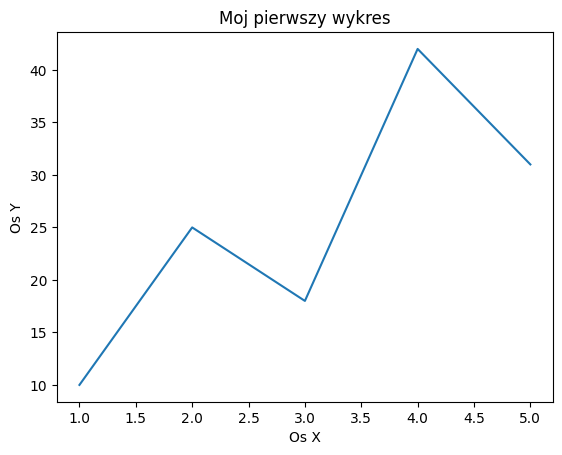

In [48]:
import matplotlib.pyplot as plt
%matplotlib inline

x = [1, 2, 3, 4, 5]
y = [10, 25, 18, 42, 31]

plt.plot(x, y)
plt.title('Moj pierwszy wykres')
plt.xlabel('Os X')
plt.ylabel('Os Y')
plt.show()

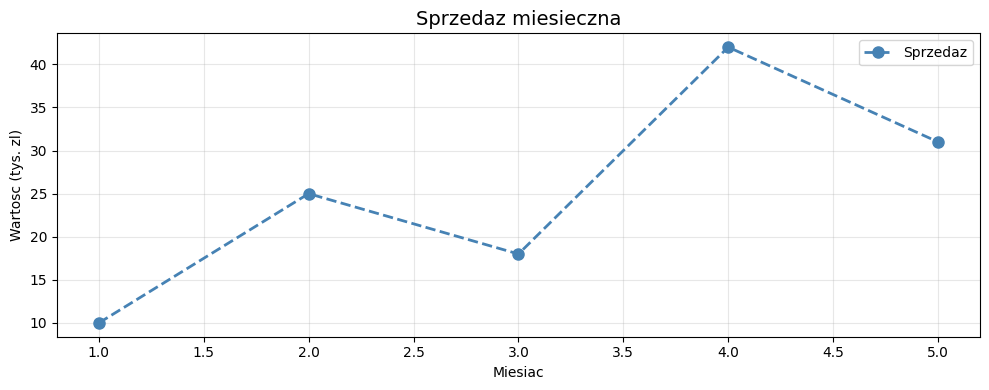

In [49]:
# fig – caly rysunek, ax – jeden wykres
# Mozemy miec wiele ax na jednym fig!

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(x, y,
        color='steelblue',
        linewidth=2,
        linestyle='--',
        marker='o',
        markersize=8,
        label='Sprzedaz')

ax.set_title('Sprzedaz miesieczna', fontsize=14)
ax.set_xlabel('Miesiac')
ax.set_ylabel('Wartosc (tys. zl)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 10.2 Wykres slupkowy – stopy zwrotu WIG20

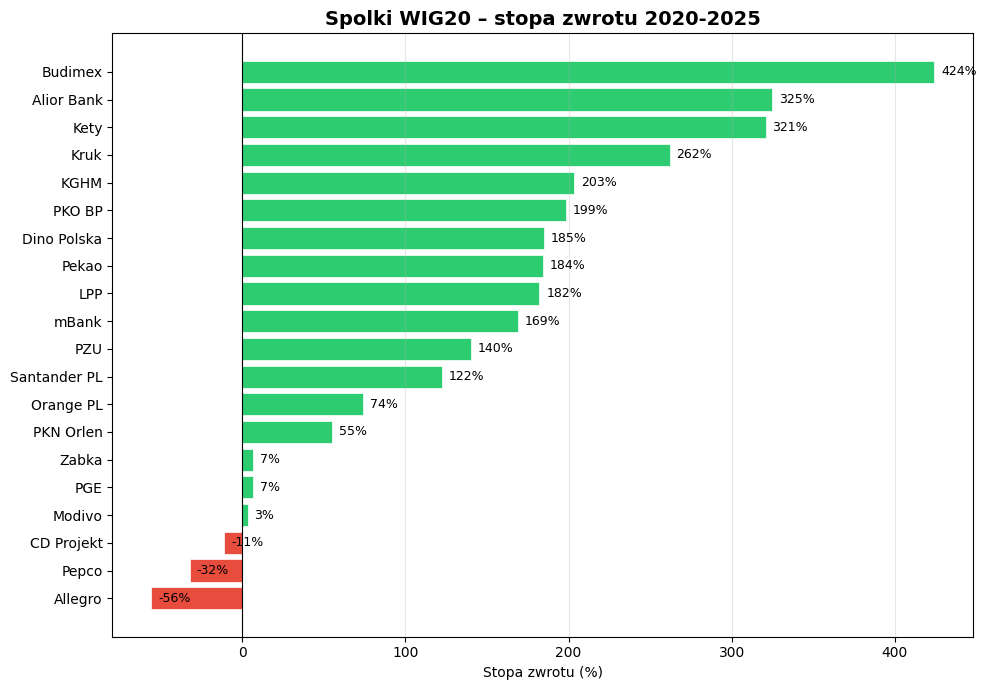

In [51]:
fig, ax = plt.subplots(figsize=(10, 7))

kolory = ['#2ecc71' if v >= 0 else '#e74c3c' for v in df_stopy['stopa_zwrotu_pct']]

bars = ax.barh(
    df_stopy['spolka'],
    df_stopy['stopa_zwrotu_pct'],
    color=kolory,
    edgecolor='white',
    linewidth=0.5
)

for bar, val in zip(bars, df_stopy['stopa_zwrotu_pct']):
    ax.text(
        val + (max(df_stopy['stopa_zwrotu_pct']) * 0.01),
        bar.get_y() + bar.get_height() / 2,
        f'{val:.0f}%',
        va='center', fontsize=9
    )

ax.set_title('Spolki WIG20 – stopa zwrotu 2020-2025', fontsize=14, fontweight='bold')
ax.set_xlabel('Stopa zwrotu (%)')
ax.axvline(0, color='black', linewidth=0.8)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### 10.3 Wykres kursu zamkniecia TOP 10 – wiele linii (normalizacja)

In [56]:
top10_tickery = top10['spolka'].tolist()
df_top10 = df_wig20[df_wig20['spolka'].isin(top10_tickery)].copy()

# Normalizacja do 100 w punkcie startowym
# Dzieki temu porownujemy spolki o roznych poziomach cen na jednej skali
def normalizuj(df_spolka):
    df_s = df_spolka.sort_values('Data').copy()
    df_s['Zamkniecie_norm'] = df_s['Zamkniecie'] / df_s['Zamkniecie'].iloc[0] * 100
    return df_s

df_top10_norm  = df_top10.groupby('ticker', group_keys=False).apply(normalizuj)
df_pivot_top10 = df_top10_norm.pivot_table(index='Data', columns='spolka', values='Zamkniecie_norm')
df_pivot_top10.head()

spolka,Alior Bank,Budimex,Dino Polska,KGHM,Kety,Kruk,LPP,PKO BP,Pekao,mBank
Data,,,,,,,,,,
2020-01-02,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2020-01-03,97.324489,104.375195,97.658402,98.181999,99.281540,99.273135,99.773903,97.970036,99.804054,100.507099
2020-01-07,95.384609,104.605296,98.691460,98.019172,101.009989,99.700746,98.812993,97.068102,98.579046,99.391481
2020-01-08,93.511675,104.265897,98.002755,96.997262,102.452437,99.519580,97.795423,96.052595,97.079243,99.492901
2020-01-09,94.515088,102.797364,100.000000,98.979171,101.734897,101.543212,98.417189,97.970036,100.731125,101.419878


In [57]:
df_pivot_top10.columns

Index(['Alior Bank', 'Budimex', 'Dino Polska', 'KGHM', 'Kety', 'Kruk', 'LPP',
       'PKO BP', 'Pekao', 'mBank'],
      dtype='str', name='spolka')

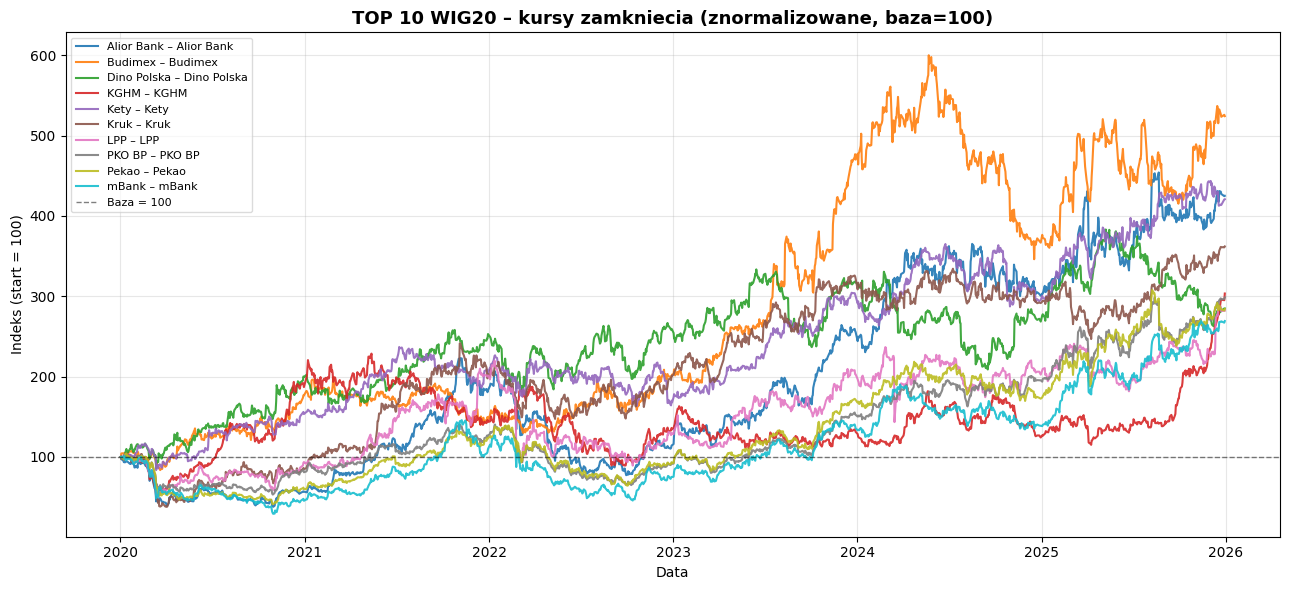

In [ ]:
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(13, 6))
kolory_linii = cm.tab10.colors   # 10 roznych kolorow

for i, ticker in enumerate(df_pivot_top10.columns):
    seria = df_pivot_top10[ticker].dropna()
    # nazwa spolki do legendy
    nazwa = top10[top10['spolka'] == ticker]['spolka'].values[0]
    ax.plot(seria.index, seria.values,
            label=f'{ticker} – {nazwa}',
            color=kolory_linii[i],
            linewidth=1.5,
            alpha=0.9)

ax.axhline(100, color='black', linewidth=1, linestyle='--', alpha=0.5, label='Baza = 100')
ax.set_title('TOP 10 WIG20 – kursy zamkniecia (znormalizowane, baza=100)', fontsize=13, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Indeks (start = 100)')
ax.legend(loc='upper left', fontsize=8, framealpha=0.7)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 10.4 Subplot – kurs i wolumen dla jednej spolki

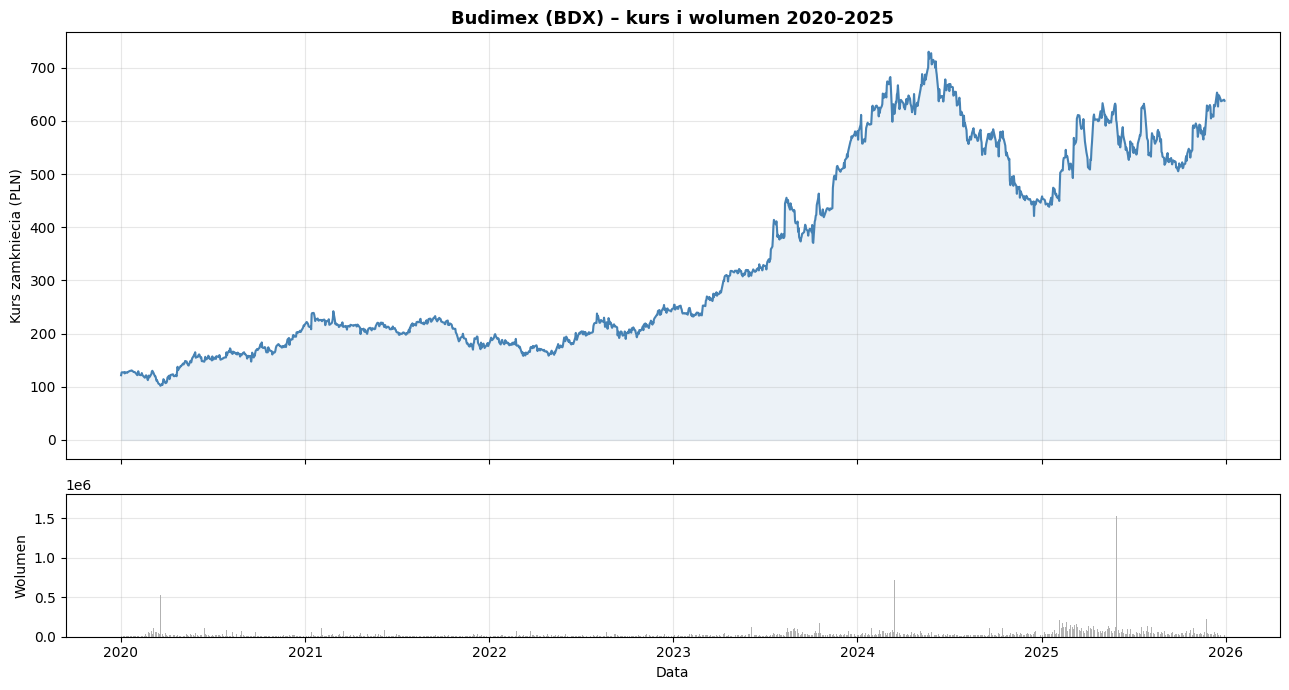

In [58]:
ticker_1 = top10.iloc[0]['ticker']
spolka_1 = top10.iloc[0]['spolka']
df_s1 = df_top10[df_top10['ticker'] == ticker_1].sort_values('Data')

# subplot – dwa wykresy jeden pod drugim ze wspolna osia X
fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(13, 7),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

ax1.plot(df_s1['Data'], df_s1['Zamkniecie'], color='steelblue', linewidth=1.5)
ax1.fill_between(df_s1['Data'], df_s1['Zamkniecie'], alpha=0.1, color='steelblue')
ax1.set_title(f'{spolka_1} ({ticker_1}) – kurs i wolumen 2020-2025', fontsize=13, fontweight='bold')
ax1.set_ylabel('Kurs zamkniecia (PLN)')
ax1.grid(True, alpha=0.3)

ax2.bar(df_s1['Data'], df_s1['Wolumen'], color='gray', alpha=0.6, width=1)
ax2.set_ylabel('Wolumen')
ax2.set_xlabel('Data')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 10.5 Zapisanie wykresu do pliku

Wykres zapisany jako top10_wig20.png


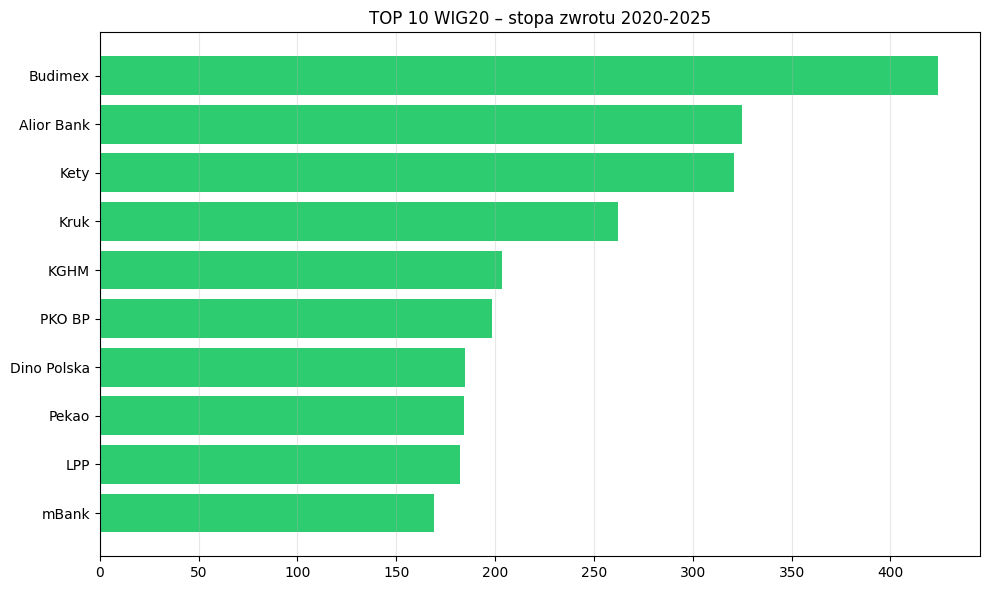

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
kolory = ['#2ecc71' if v >= 0 else '#e74c3c' for v in top10['stopa_zwrotu_pct']]
ax.barh(top10['spolka'], top10['stopa_zwrotu_pct'], color=kolory)
ax.set_title('TOP 10 WIG20 – stopa zwrotu 2020-2025')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()

# Format rozpoznawany po rozszerzeniu: .png, .pdf, .svg
plt.savefig('top10_wig20.png', dpi=150, bbox_inches='tight')
print("Wykres zapisany jako top10_wig20.png")
plt.show()

---
## 11. ZADANIA

In [30]:
### ZADANIE 1 ###
# Zmodyfikuj funkcje pobierz_dane_odporna() tak,
# zeby przyjmowala parametr max_retries=3 i ponawiala
# probe polaczenia w razie bledu Timeout lub ConnectionError.
# Miedzy probami dodaj przerwe time.sleep(2).

# Twoj kod tutaj:


In [31]:
# Rozwiazanie:
def pobierz_dane_z_retry(ticker, data_od='2020-01-01', data_do='2025-12-31',
                          nazwa=None, max_retries=3):
    d1  = data_od.replace('-', '')
    d2  = data_do.replace('-', '')
    url = f'https://stooq.pl/q/d/l/?s={ticker}&d1={d1}&d2={d2}&i=d'

    for proba in range(1, max_retries + 1):
        try:
            response = requests.get(url, headers=HEADERS, timeout=10)
            response.raise_for_status()
            break
        except (requests.exceptions.Timeout, requests.exceptions.ConnectionError) as e:
            print(f"  [{ticker}] Proba {proba}/{max_retries} nieudana: {e}")
            if proba < max_retries:
                time.sleep(2)
            else:
                print(f"  [{ticker}] Wszystkie proby wyczerpane")
                return None
        except requests.exceptions.RequestException as e:
            print(f"  [{ticker}] Blad: {e}")
            return None

    try:
        df = pd.read_csv(io.StringIO(response.text))
        if 'Data' not in df.columns or len(df) == 0:
            return None
        df['Data']   = pd.to_datetime(df['Data'])
        df['ticker'] = ticker.upper()
        df['spolka'] = nazwa or ticker.upper()
        return df.sort_values('Data').reset_index(drop=True)
    except Exception as e:
        print(f"  [{ticker}] Blad parsowania: {e}")
        return None

df_test = pobierz_dane_z_retry('pko', nazwa='PKO BP')
print(f"Pobrano {len(df_test)} wierszy")

Pobrano 1502 wierszy


In [ ]:
### ZADANIE 2 ###
# Narysuj wykres kolowy (pie chart) pokazujacy rozklad spolek WIG20
# wg stopy zwrotu: ile spolek ma zwrot > 100%, 0-100%, ujemny?
# Uzyj ax.pie()

# Twoj kod tutaj:


In [ ]:
# Rozwiazanie:
def kategoria_zwrotu(stopa):
    if stopa > 100:
        return 'Ponad +100%'
    elif stopa > 0:
        return '0% do +100%'
    else:
        return 'Ujemna'

df_stopy['kategoria'] = df_stopy['stopa_zwrotu_pct'].apply(kategoria_zwrotu)
rozklad = df_stopy['kategoria'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    rozklad.values,
    labels=rozklad.index,
    autopct='%1.1f%%',
    colors=['#2ecc71', '#3498db', '#e74c3c'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax.set_title('Rozklad stop zwrotu 2020-2025 - WIG20', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
### ZADANIE 3 - ZLOZOONE ###
# Wybierz 3 spolki z TOP 10.
# Dla kazdej oblicz 30-dniowa i 90-dniowa srednia kroczaca kursu zamkniecia.
# Narysuj na jednym wykresie (3 subploty w kolumnie) kurs + obie srednie kroczace.
# Dodaj legende i tytuly.
# Wskazowka: .rolling(window=N).mean()

# Twoj kod tutaj:
